NaNs present
non-NaN mean, std =  2.169986269563819 0.4745140140980093
updated mean, std =  2.173269045427578 0.4629566451638146


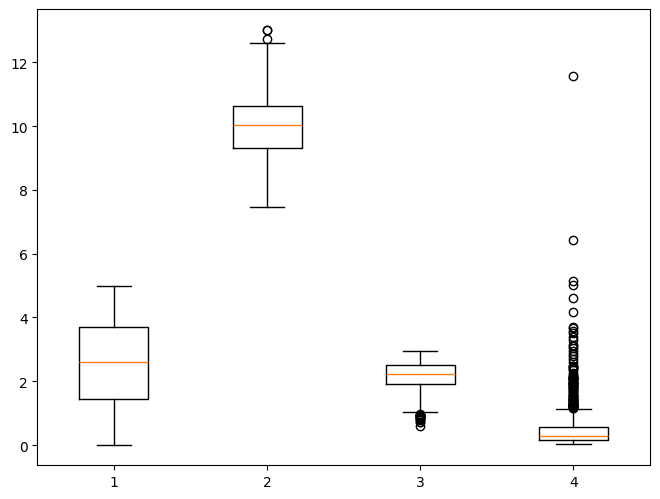

In [2]:
#  Missing data example
import numpy as np
import matplotlib.pylab as plt

N = 1000
np.random.seed(73939133)
x = np.zeros((N,4))
x[:,0] = 5*np.random.random(N)
x[:,1] = np.random.normal(10,1,size=N)
x[:,2] = 3*np.random.beta(5,2,N)
x[:,3] = 0.3*np.random.lognormal(size=N)

plt.boxplot(x)
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig("missing_box_plot.png", dpi=300)
plt.close()

#  Make 5% of the values NaN
i = np.random.randint(0,N, size=int(0.05*N))
x[i,0] = np.nan
i = np.random.randint(0,N, size=int(0.05*N))
x[i,1] = np.nan
i = np.random.randint(0,N, size=int(0.05*N))
x[i,2] = np.nan
i = np.random.randint(0,N, size=int(0.05*N))
x[i,3] = np.nan

#  Do we have NaNs in feature 2?
if (np.isnan(x[:,2]).sum() != 0):
    print("NaNs present")
    i = np.where(np.isnan(x[:,2]) == False)
    z = x[i,2]
    mn,md,s = z.mean(), np.median(z), z.std(ddof=1)
    hh,xx = np.histogram(z, bins=40)
    plt.bar(xx[:-1],hh, width=0.8*(xx[1]-xx[0]))
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout(pad=0, w_pad=0, h_pad=0)
    plt.savefig("missing_feature_2_plot.png", dpi=300)
    plt.close()

    i = np.where(np.isnan(x[:,2]) == True)
    x[i,2] = md  # replace w/median
    
    print("non-NaN mean, std = ", z.mean(), z.std(ddof=1))
    print("updated mean, std = ", x[:,2].mean(), x[:,2].std(ddof=1))

    hh,xx = np.histogram(x[:,2], bins=40)
    plt.bar(xx[:-1],hh, width=0.8*(xx[1]-xx[0]))
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout(pad=0, w_pad=0, h_pad=0)
    plt.savefig("missing_feature_2_updated_plot.png", dpi=300)
    plt.close()

#  Do the same to the others
i = np.where(np.isnan(x[:,0]) == False)
m = np.median(x[i,0])
i = np.where(np.isnan(x[:,0]) == True)
x[i,0] = m

i = np.where(np.isnan(x[:,1]) == False)
m = np.median(x[i,1])
i = np.where(np.isnan(x[:,1]) == True)
x[i,1] = m

i = np.where(np.isnan(x[:,3]) == False)
m = np.median(x[i,3])
i = np.where(np.isnan(x[:,3]) == True)
x[i,3] = m

plt.boxplot(x)
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.show()
#plt.savefig("missing_updated_box_plot.png", dpi=300)
#plt.close()





 박스플롯(Boxplot)은 4가지 특징(Features)의 데이터 분포 특성을 나란히 보여줍니다. 각 피처의 박스플롯 형태는 생성된 난수 분포 특성에 따라 다음과 같이 나타납니다:

1. **첫 번째 피처 `x[:, 0]` (균등 분포, Uniform Distribution)**
   - `5*np.random.random(N)`으로 생성되어 0부터 5 사이의 값을 고르게 가집니다.
   - 박스플롯은 대략 0에서 5 사이에 넓게 걸쳐 있으며, 중앙값(주황색 선)은 약 2.5 부근에 위치합니다. 데이터가 균일하기 때문에 이상치(Outlier, 동그란 점)가 거의 나타나지 않습니다.

2. **두 번째 피처 `x[:, 1]` (정규 분포, Normal Distribution)**
   - `np.random.normal(10, 1, size=N)`으로 평균 10, 표준편차 1을 가집니다.
   - 값들이 10을 중심으로 대칭적인 종 모양으로 모여 있으므로, 박스가 10 부근에 짧고 굵게 형성됩니다. 정규분포 특성상 꼬리에 해당하는 위아래 양쪽 끝에 소수의 이상치 점들이 나타납니다. 다른 피처들에 비해 y축 위치가 가장 높습니다.

3. **세 번째 피처 `x[:, 2]` (베타 분포, Beta Distribution)**
   - `3*np.random.beta(5, 2, N)`으로 생성되어 0에서 3 범위를 가집니다.
   - 매개변수가 $\alpha=5$, $\beta=2$인 베타분포이므로 큰 값(우측)으로 쏠려 있는 분포(Right-skewed, 왼쪽으로 꼬리가 길게 늘어짐)를 가집니다. 따라서 중앙값이 박스 윗부분에 치우쳐 있을 수 있으며, 작은 값 쪽(아래쪽)으로 이상치가 나타날 수 있습니다.

4. **네 번째 피처 `x[:, 3]` (로그-정규 분포, Lognormal Distribution)**
   - `0.3*np.random.lognormal(size=N)`으로 생성되었습니다.
   - 로그-정규 분포는 전형적으로 한쪽(오른쪽)으로 꼬리가 매우 긴 극단적인 비대칭 형태를 가집니다.
   - 박스 자체는 y축 0 부근의 매우 좁은 구간에 눌려 있고 중앙값도 매우 낮습니다. 하지만 위쪽(큰 값 방향)으로 아주 길게 뻗은 점(이상치)들이 길게 띠를 이루며 나타나는 형태를 보입니다.

**결측치 대체의 영향:**
- 데이터 내부에서 각 열당 5%씩 결측치(NaN)를 만들어 낸 후, 이를 **해당 열의 중앙값(Median)**으로 대체했습니다.
- 중앙값 대체를 사용했기 때문에, 원래의 데이터 형태와 분포의 중심(박스플롯의 구조)이 크게 왜곡되지 않고 그대로 반영될 수 있음을 이 박스플롯이 보여주는 핵심 분석 결과입니다.

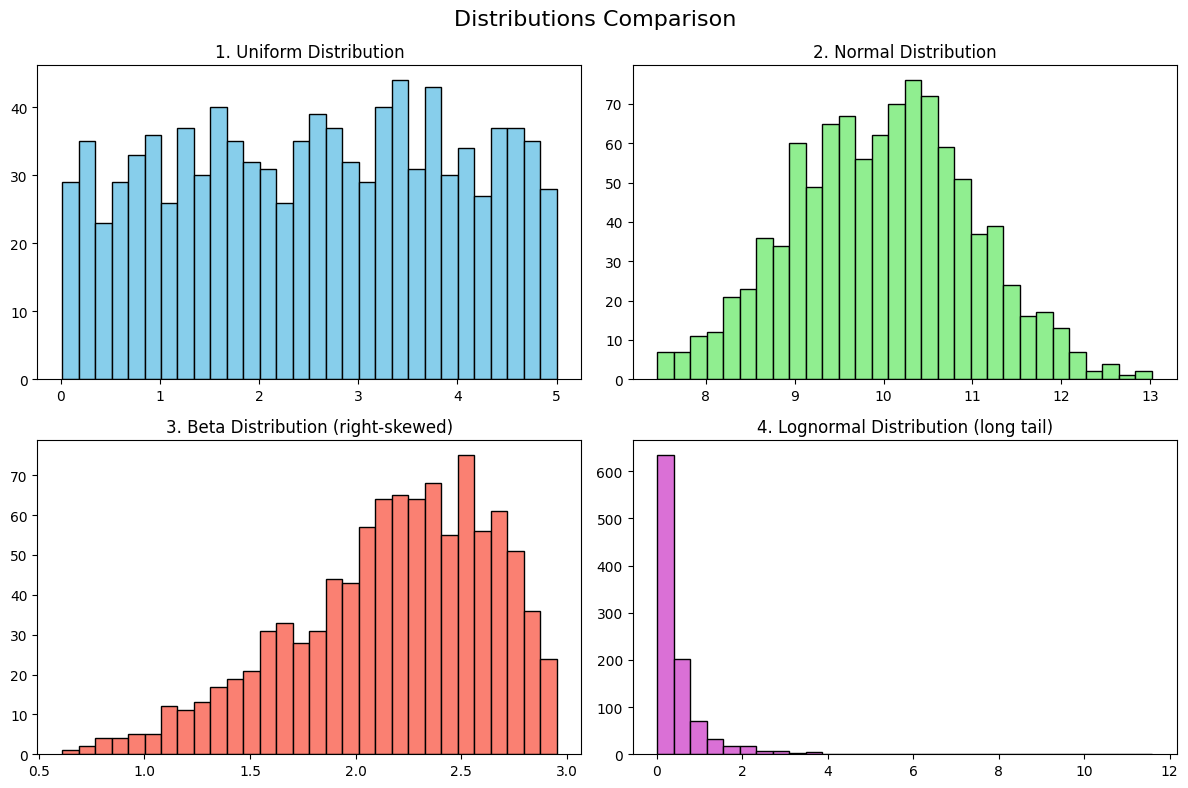

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
np.random.seed(73939133)

# 4가지 분포 확률 변수 생성
x_uniform = 5 * np.random.random(N)
x_normal = np.random.normal(10, 1, size=N)
x_beta = 3 * np.random.beta(5, 2, N)
x_lognormal = 0.3 * np.random.lognormal(size=N)

# 2x2 그래프 레이아웃 설정
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# 1. 균등 분포 (Uniform Distribution)
axs[0, 0].hist(x_uniform, bins=30, color='skyblue', edgecolor='black')
axs[0, 0].set_title('1. Uniform Distribution')

# 2. 정규 분포 (Normal Distribution)
axs[0, 1].hist(x_normal, bins=30, color='lightgreen', edgecolor='black')
axs[0, 1].set_title('2. Normal Distribution')

# 3. 베타 분포 (Beta Distribution)
axs[1, 0].hist(x_beta, bins=30, color='salmon', edgecolor='black')
axs[1, 0].set_title('3. Beta Distribution (right-skewed)')

# 4. 로그-정규 분포 (Lognormal Distribution)
axs[1, 1].hist(x_lognormal, bins=30, color='orchid', edgecolor='black')
axs[1, 1].set_title('4. Lognormal Distribution (long tail)')

fig.suptitle('Distributions Comparison', fontsize=16)
plt.tight_layout()
plt.show()